# MCDI501: Estadística Computacional para la Toma de Decisiones
## Evaluación Sumativa 1 — Fase 2: Análisis Exploratorio e Inferencial
### Dataset: Default of Credit Card Clients (UCI, Taiwan 2005)

| | |
|---|---|
| **Integrantes** | Arturo Knopke Vera · Nicolás Soletic Cobos · Sebastián Navarrete Soto · Roberto Moncada González |
| **Docente** | Jean Paul Maidana |
| **Fecha** | 24 de junio de 2026 |
| **Repositorio** | https://github.com/robertomoncada-blip/Magister_ciencia_datos |

---

## Objetivo del Notebook

Aplicar procedimientos de estadística descriptiva, estimación paramétrica y pruebas de hipótesis sobre el dataset *Default of Credit Card Clients*, con el fin de caracterizar el comportamiento de pago de clientes de tarjetas de crédito en Taiwán (2005) y apoyar la **toma de decisiones bajo incertidumbre** en gestión de riesgo crediticio.

Los resultados obtenidos permiten estimar parámetros poblacionales relevantes para la gestión del riesgo, identificar variables asociadas al incumplimiento y formular una base estadística para decisiones como el ajuste de límites de crédito, la priorización de acciones de cobranza y la segmentación de clientes por nivel de riesgo.

### Estructura
1. Carga y exploración inicial
2. Análisis y tratamiento de valores faltantes
3. Preprocesamiento
4. **Estadística descriptiva** *(ID1.2)*
5. **Estimación puntual e intervalos de confianza** *(ID1.3)*
6. **Prueba de hipótesis** *(ID1.4)*
7. Resumen de resultados e interpretación preliminar
8. Conclusiones generales
9. Referencias

## 0. Importaciones y Configuración

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, norm
import warnings

warnings.filterwarnings('ignore')

# Estilos
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (10, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Ruta al módulo src
sys.path.append('../src')
from data_loading import cargar_datos

print("Librerías cargadas correctamente.")
print(f"Pandas: {pd.__version__}  |  NumPy: {np.__version__}  |  SciPy: {scipy.__version__}")


Librerías cargadas correctamente.
Pandas: 3.0.3  |  NumPy: 2.4.6  |  SciPy: 1.17.1


## 1. Carga y Exploración Inicial

Se carga el dataset `UCI_Credit_Card_con_faltantes.csv`, que corresponde a la versión del dataset
con valores faltantes introducidos de forma controlada bajo el mecanismo **MCAR** (*Missing Completely At Random*)
con semilla 42, simulando condiciones reales de datos incompletos.

In [2]:
df_raw = cargar_datos('../data/raw/UCI_Credit_Card_con_faltantes.csv')
print(f"\nDimensiones: {df_raw.shape[0]:,} filas  ×  {df_raw.shape[1]} columnas")
df_raw.head(5)


Datos cargados: 30000 filas y 25 columnas.

Dimensiones: 30,000 filas  ×  25 columnas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,NaN,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1.0,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0.0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0.0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1.0,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
print("─" * 55)
print("INFORMACIÓN GENERAL DEL DATASET")
print("─" * 55)
df_raw.info()

───────────────────────────────────────────────────────
INFORMACIÓN GENERAL DEL DATASET
───────────────────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   26250 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       26250 non-null  float64
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6       

In [4]:
# Verificación de duplicados e inconsistencias (calidad de datos)
print("─" * 55)
print("DUPLICADOS E INCONSISTENCIAS")
print("─" * 55)

# Duplicados
dup_con_id = df_raw.duplicated().sum()
cols_sin_id = [c for c in df_raw.columns if c.upper() != 'ID']
dup_sin_id = df_raw.duplicated(subset=cols_sin_id).sum()
print(f"Filas duplicadas (incluyendo ID): {dup_con_id}")
print(f"Perfiles repetidos (excluyendo ID): {dup_sin_id}")

# Inconsistencias en variables categóricas (códigos fuera del diccionario oficial)
edu_invalidos = df_raw[~df_raw['EDUCATION'].isin([1, 2, 3])].shape[0]
mar_invalidos = df_raw[df_raw['MARRIAGE'] == 0].shape[0]
print(f"\nEDUCATION con códigos no principales (0, 4, 5, 6): {edu_invalidos}")
print(df_raw['EDUCATION'].value_counts().sort_index().to_string())
print(f"\nMARRIAGE con código no documentado (0): {mar_invalidos}")
print(df_raw['MARRIAGE'].value_counts().sort_index().to_string())

───────────────────────────────────────────────────────
DUPLICADOS E INCONSISTENCIAS
───────────────────────────────────────────────────────
Filas duplicadas (incluyendo ID): 0
Perfiles repetidos (excluyendo ID): 26

EDUCATION con códigos no principales (0, 4, 5, 6): 468
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

MARRIAGE con código no documentado (0): 54
MARRIAGE
0       54
1    13659
2    15964
3      323


## 2. Análisis y Tratamiento de Valores Faltantes

### 2.1 Identificación de faltantes

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
tabla_missing = pd.DataFrame({
    'Valores Faltantes': missing,
    'Porcentaje (%)': missing_pct
}).query('`Valores Faltantes` > 0')

print("Variables con valores faltantes:")
print(tabla_missing.to_string())
print(f"\nTotal de registros: {len(df_raw):,}")


Variables con valores faltantes:
           Valores Faltantes  Porcentaje (%)
LIMIT_BAL               3750            12.5
PAY_0                   3750            12.5

Total de registros: 30,000


### 2.2 Verificación del Mecanismo de Datos Faltantes (MCAR)

Los datos faltantes fueron introducidos por diseño con mecanismo **MCAR** (semilla 42), lo que significa
que la ausencia de un valor es **independiente** tanto del valor de la variable como de cualquier
otra variable del dataset. Como comprobación parcial consistente con este mecanismo, se compara la
distribución de `AGE` entre el grupo con y sin `LIMIT_BAL` faltante; esta prueba es consistente con
MCAR, pero no constituye una verificación global del mecanismo para todas las variables.

**Hipótesis para verificar MCAR:**
- H₀: No existe diferencia significativa en la distribución de `AGE` entre registros con y sin `LIMIT_BAL`
- H₁: Existe diferencia → los faltantes no son MCAR

**Estrategia de imputación:**
- `LIMIT_BAL` (variable continua): imputación con la **mediana** (robusta ante valores extremos)
- `PAY_0` (variable ordinal): imputación con la **moda** (valor más frecuente: 0)

───────────────────────────────────────────────────────
PRUEBA MCAR: t-test AGE (faltante vs completo)
───────────────────────────────────────────────────────
Media AGE  (con faltante LIMIT_BAL): 35.54
Media AGE  (sin faltante LIMIT_BAL): 35.48
Estadístico t = 0.3577  |  p-value = 0.7206
→ No se rechaza H₀ (p > 0.05): consistente con mecanismo MCAR ✓


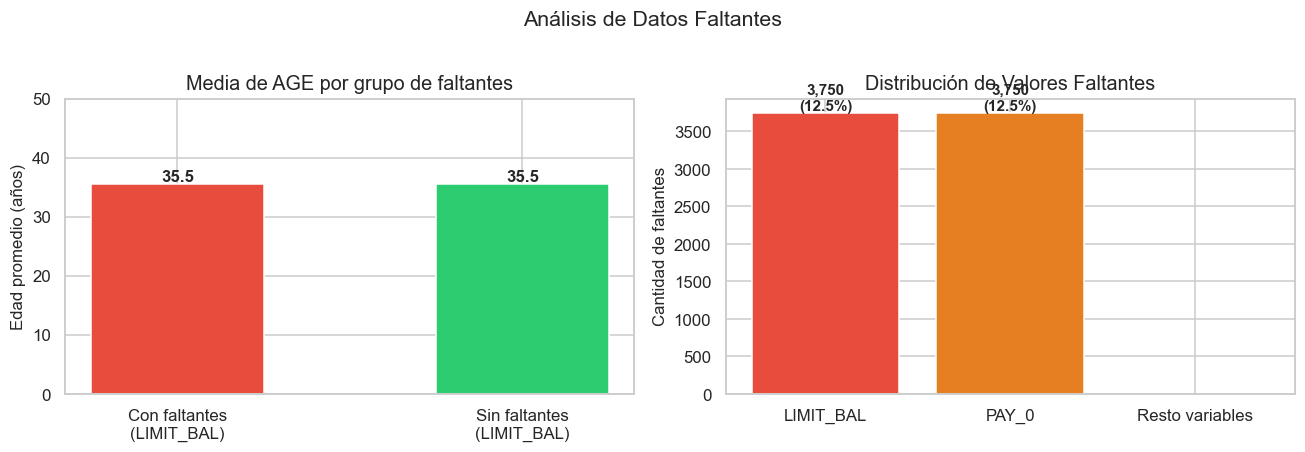

In [6]:
# Verificar MCAR: comparar AGE entre grupos con/sin LIMIT_BAL faltante
mask_faltante = df_raw['LIMIT_BAL'].isnull()

age_faltante = df_raw.loc[mask_faltante, 'AGE'].dropna()
age_completo = df_raw.loc[~mask_faltante, 'AGE'].dropna()

t_stat, p_val = ttest_ind(age_faltante, age_completo, equal_var=False)

print("─" * 55)
print("PRUEBA MCAR: t-test AGE (faltante vs completo)")
print("─" * 55)
print(f"Media AGE  (con faltante LIMIT_BAL): {age_faltante.mean():.2f}")
print(f"Media AGE  (sin faltante LIMIT_BAL): {age_completo.mean():.2f}")
print(f"Estadístico t = {t_stat:.4f}  |  p-value = {p_val:.4f}")
if p_val > 0.05:
    print("→ No se rechaza H₀ (p > 0.05): consistente con mecanismo MCAR ✓")
else:
    print("→ Se rechaza H₀: posible MAR o MNAR")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Con faltantes\n(LIMIT_BAL)', 'Sin faltantes\n(LIMIT_BAL)'],
            [age_faltante.mean(), age_completo.mean()],
            color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('Media de AGE por grupo de faltantes')
axes[0].set_ylabel('Edad promedio (años)')
axes[0].set_ylim(0, 50)
for i, v in enumerate([age_faltante.mean(), age_completo.mean()]):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

missing_summary = pd.Series({
    'LIMIT_BAL': df_raw['LIMIT_BAL'].isnull().sum(),
    'PAY_0': df_raw['PAY_0'].isnull().sum(),
    'Resto variables': 0
})
axes[1].bar(missing_summary.index, missing_summary.values,
            color=['#e74c3c', '#e67e22', '#95a5a6'], edgecolor='white')
axes[1].set_title('Distribución de Valores Faltantes')
axes[1].set_ylabel('Cantidad de faltantes')
for i, v in enumerate(missing_summary.values):
    if v > 0:
        axes[1].text(i, v + 30, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
                     ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Análisis de Datos Faltantes', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_faltantes.png', bbox_inches='tight', dpi=110)
plt.show()


## 3. Preprocesamiento

In [7]:
df = df_raw.copy()

# 3.1 Imputar valores faltantes
mediana_limit = df['LIMIT_BAL'].median()
moda_pay0 = int(df['PAY_0'].mode()[0])

df['LIMIT_BAL'] = df['LIMIT_BAL'].fillna(mediana_limit)
df['PAY_0']     = df['PAY_0'].fillna(moda_pay0)

print(f"LIMIT_BAL imputado con mediana = NT${mediana_limit:,.0f}")
print(f"PAY_0 imputado con moda = {moda_pay0}")
print(f"Faltantes restantes: {df.isnull().sum().sum()}")

# 3.2 Eliminar columna ID (no aporta valor analítico)
df = df.drop(columns=['ID'])

# 3.3 Tipado adecuado
categoricas = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df[categoricas] = df[categoricas].astype('category')
df['default.payment.next.month'] = df['default.payment.next.month'].astype('uint8')

monetarias = ['LIMIT_BAL',
              'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
              'PAY_AMT1',  'PAY_AMT2',  'PAY_AMT3',  'PAY_AMT4',  'PAY_AMT5',  'PAY_AMT6']
df[monetarias] = df[monetarias].astype('float64')

print(f"\nDataset listo para análisis:")
print(f"  Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"  Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


LIMIT_BAL imputado con mediana = NT$140,000
PAY_0 imputado con moda = 0
Faltantes restantes: 0

Dataset listo para análisis:
  Filas: 30,000  |  Columnas: 24
  Memoria: 3.5 MB


## 4. Estadística Descriptiva *(ID1.2)*

### 4.1 Catálogo de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| LIMIT_BAL | Numérica continua | Límite de crédito otorgado (NT$) |
| SEX | Categórica binaria | Género (1=masculino, 2=femenino) |
| EDUCATION | Categórica ordinal | Nivel educacional (1=posgrado, 2=universidad, 3=secundaria, 4+=otros) |
| MARRIAGE | Categórica nominal | Estado civil (1=casado, 2=soltero, 3=otro) |
| AGE | Numérica discreta | Edad en años |
| PAY_0 – PAY_6 | Categórica ordinal | Estado de pago meses sep–abr 2005 (-1=al día, 1-9=meses de atraso; códigos -2 y 0 sin definición documentada en la fuente) |
| BILL_AMT1–6 | Numérica continua | Monto de factura mensual (NT$), sep–abr 2005 |
| PAY_AMT1–6 | Numérica continua | Monto de pago previo mensual (NT$), sep–abr 2005 |
| default.payment.next.month | Binaria (target) | Incumplimiento de pago (1=sí, 0=no) |

### 4.2 Estadísticas Descriptivas — Variables Numéricas Continuas

In [8]:
numericas_clave = ['LIMIT_BAL', 'AGE',
                   'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                   'PAY_AMT1',  'PAY_AMT2',  'PAY_AMT3']

def resumen_estadistico(df, cols):
    filas = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        filas.append({
            'Variable'         : col,
            'N'                : len(s),
            'Media'            : round(s.mean(), 2),
            'Mediana'          : round(s.median(), 2),
            'Moda'             : round(float(s.mode()[0]), 2),
            'Desv. Estándar'   : round(s.std(), 2),
            'Min'              : round(s.min(), 2),
            'Q1'               : round(q1, 2),
            'Q3'               : round(q3, 2),
            'Max'              : round(s.max(), 2),
            'IQR'              : round(q3 - q1, 2),
            'Asimetría'        : round(s.skew(), 3),
            'Curtosis'         : round(s.kurtosis(), 3),
        })
    return pd.DataFrame(filas).set_index('Variable')

tabla_desc = resumen_estadistico(df, numericas_clave)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 15)
tabla_desc


,N,Media,Mediana,Moda,Desv. Estándar,Min,Q1,Q3,Max,IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,
LIMIT_BAL,30000,"164,246.66","140,000.00","140,000.00","122,191.09","10,000.00","70,000.00","220,000.00","1,000,000.00","150,000.00",1.13,1.10
AGE,30000,35.49,34.00,29.00,9.22,21.00,28.00,41.00,79.00,13.00,0.73,0.04
BILL_AMT1,30000,"51,223.33","22,381.50",0.00,"73,635.86","-165,580.00","3,558.75","67,091.00","964,511.00","63,532.25",2.66,9.81
BILL_AMT2,30000,"49,179.08","21,200.00",0.00,"71,173.77","-69,777.00","2,984.75","64,006.25","983,931.00","61,021.50",2.71,10.30
BILL_AMT3,30000,"47,013.15","20,088.50",0.00,"69,349.39","-157,264.00","2,666.25","60,164.75","1,664,089.00","57,498.50",3.09,19.78
PAY_AMT1,30000,"5,663.58","2,100.00",0.00,"16,563.28",0.00,"1,000.00","5,006.00","873,552.00","4,006.00",14.67,415.25
PAY_AMT2,30000,"5,921.16","2,009.00",0.00,"23,040.87",0.00,833.00,"5,000.00","1,684,259.00","4,167.00",30.45,"1,641.63"
PAY_AMT3,30000,"5,225.68","1,800.00",0.00,"17,606.96",0.00,390.00,"4,505.00","896,040.00","4,115.00",17.22,564.31


**Interpretación:**
- `LIMIT_BAL` presenta alta asimetría positiva (larga cola a la derecha), lo que indica que la mayoría de los clientes tiene límites de crédito moderados, pero existe un grupo pequeño con límites muy altos. La mediana (NT\$140,000) es más representativa que la media (NT\$164,247).
- `AGE` tiene una distribución más simétrica, con media y mediana cercanas (~35 años).
- Las variables de facturas (`BILL_AMT*`) muestran alta variabilidad y asimetría, reflejando heterogeneidad en los niveles de endeudamiento.

### 4.3 Distribución de Variables Numéricas Clave

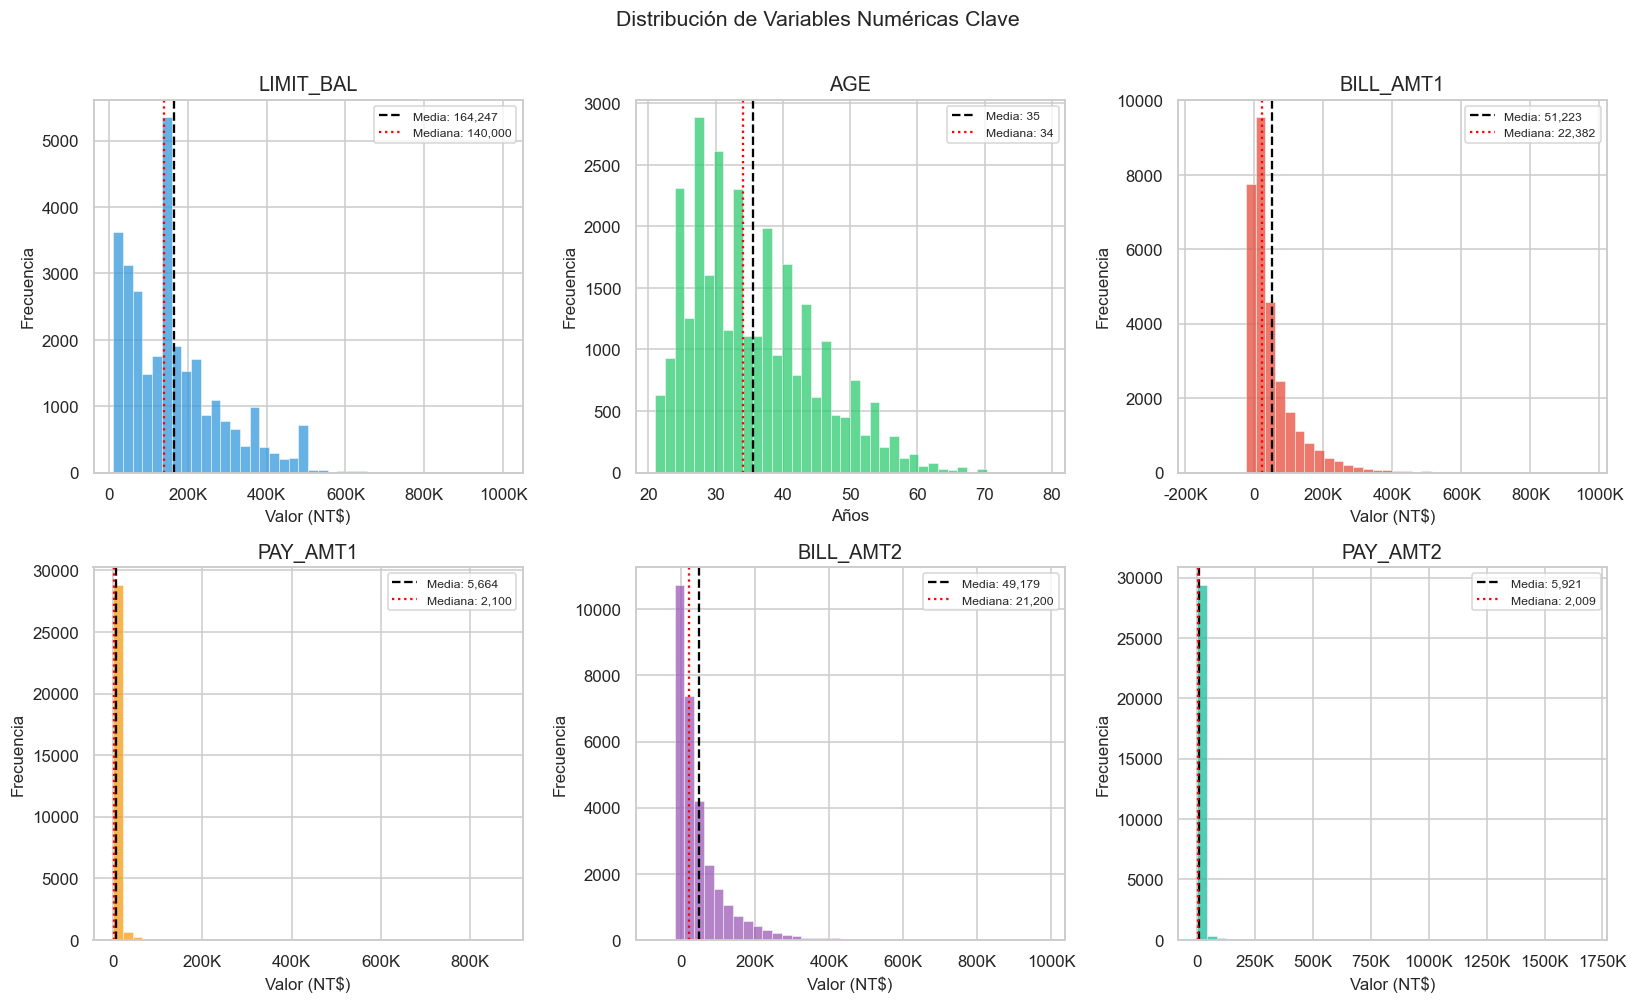

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

vars_plot = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'BILL_AMT2', 'PAY_AMT2']
colores   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for i, (var, color) in enumerate(zip(vars_plot, colores)):
    ax = axes[i]
    data = df[var].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),   color='black',  linestyle='--', linewidth=1.5, label=f'Media: {data.mean():,.0f}')
    ax.axvline(data.median(), color='red',    linestyle=':',  linewidth=1.5, label=f'Mediana: {data.median():,.0f}')
    ax.set_title(var)
    ax.set_xlabel('Valor (NT$)' if var not in ['AGE'] else 'Años')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if abs(x) >= 1000 else f'{x:.0f}'))

plt.suptitle('Distribución de Variables Numéricas Clave', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_histogramas.png', bbox_inches='tight', dpi=110)
plt.show()


### 4.4 Boxplots: Variables Numéricas por Estado de Incumplimiento

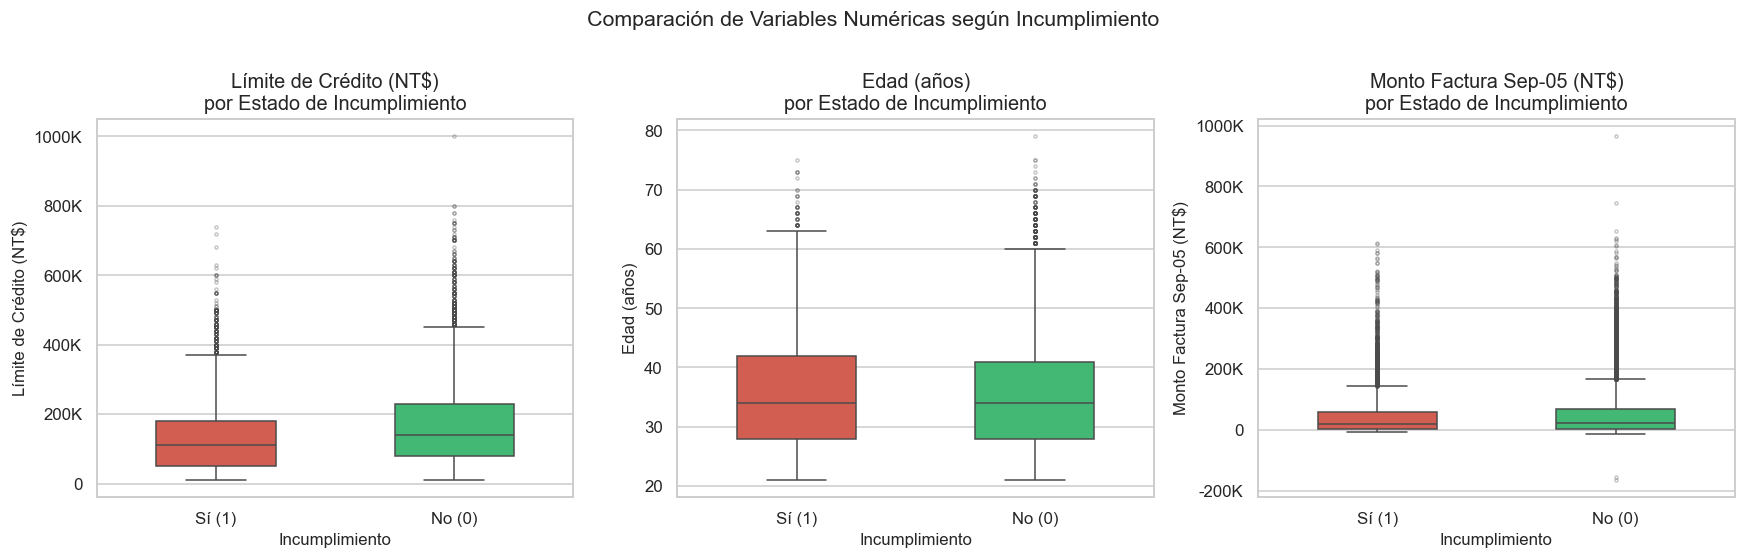


Media de variables clave por estado de incumplimiento:
                            LIMIT_BAL   AGE  BILL_AMT1
default.payment.next.month                            
No Default                 173,619.76 35.42  51,994.23
Default                    131,245.88 35.73  48,509.16


In [10]:
df_plot = df.copy()
df_plot['Default'] = df_plot['default.payment.next.month'].map({0: 'No (0)', 1: 'Sí (1)'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vars_box = ['LIMIT_BAL', 'AGE', 'BILL_AMT1']
titulos  = ['Límite de Crédito (NT$)', 'Edad (años)', 'Monto Factura Sep-05 (NT$)']

for i, (var, titulo) in enumerate(zip(vars_box, titulos)):
    sns.boxplot(
        data=df_plot, x='Default', y=var, ax=axes[i],
        palette={'No (0)': '#2ecc71', 'Sí (1)': '#e74c3c'},
        width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    axes[i].set_title(f'{titulo}\npor Estado de Incumplimiento')
    axes[i].set_xlabel('Incumplimiento')
    axes[i].set_ylabel(titulo)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1e3:.0f}K' if abs(x) >= 1000 else f'{x:.0f}'
    ))

plt.suptitle('Comparación de Variables Numéricas según Incumplimiento', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_boxplots.png', bbox_inches='tight', dpi=110)
plt.show()

# Medias por grupo
print("\nMedia de variables clave por estado de incumplimiento:")
print(df.groupby('default.payment.next.month')[vars_box].mean().round(2).rename(
    index={0: 'No Default', 1: 'Default'}
).to_string())


### 4.5 Variables Categóricas

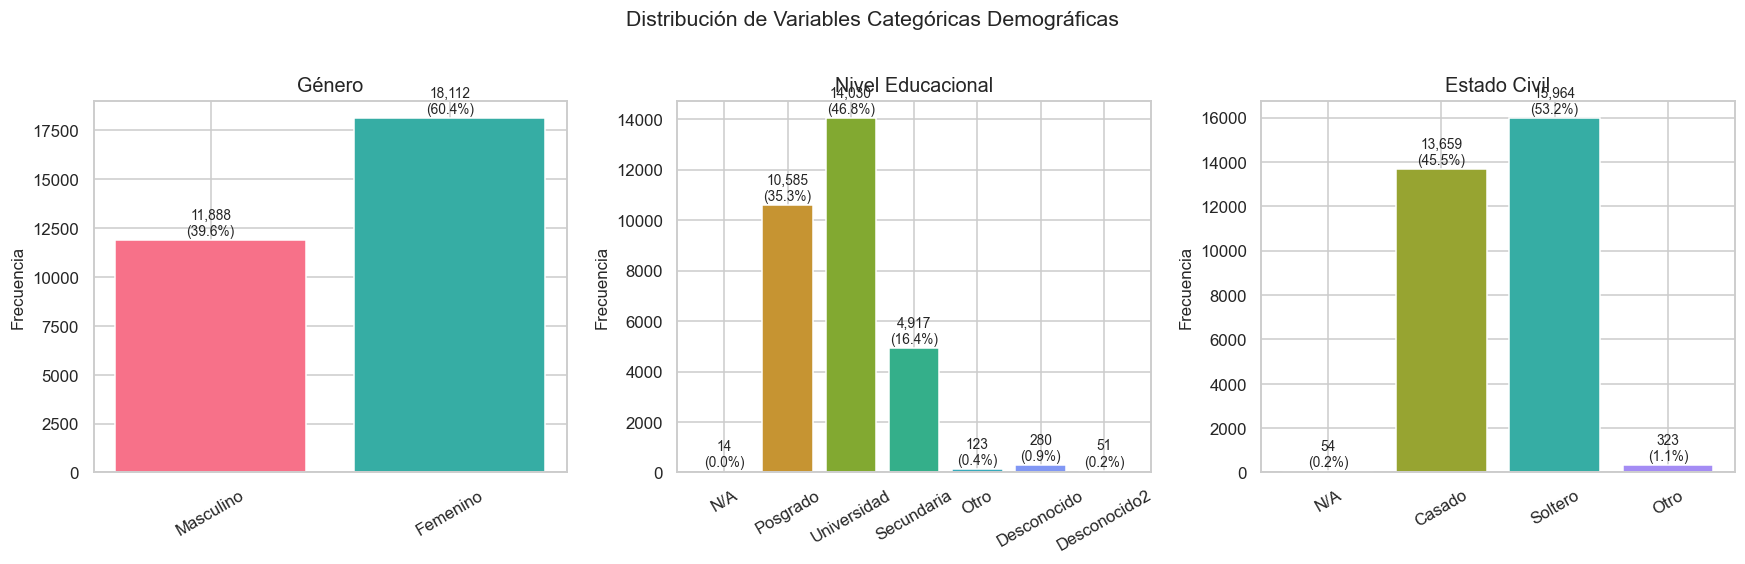

In [11]:
# Etiquetas descriptivas
label_sex       = {1: 'Masculino', 2: 'Femenino'}
label_education = {1: 'Posgrado', 2: 'Universidad', 3: 'Secundaria', 4: 'Otro', 5: 'Desconocido', 6: 'Desconocido2', 0: 'N/A'}
label_marriage  = {1: 'Casado', 2: 'Soltero', 3: 'Otro', 0: 'N/A'}
label_pay       = {-2: 'Sin consumo', -1: 'Al día', 0: 'Rotativo', 1: '1 mes', 2: '2 meses',
                    3: '3 meses', 4: '4 meses', 5: '5 meses', 6: '6 meses', 7: '7 meses',
                    8: '8 meses', 9: '9+ meses'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cats = [
    ('SEX', label_sex, 'Género', axes[0]),
    ('EDUCATION', label_education, 'Nivel Educacional', axes[1]),
    ('MARRIAGE', label_marriage, 'Estado Civil', axes[2]),
]

for col, labels, titulo, ax in cats:
    vc = df[col].value_counts().sort_index()
    nombres = [labels.get(int(k), str(k)) for k in vc.index]
    colores_bar = sns.color_palette("husl", len(vc))
    bars = ax.bar(nombres, vc.values, color=colores_bar, edgecolor='white')
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vc.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribución de Variables Categóricas Demográficas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_categoricas.png', bbox_inches='tight', dpi=110)
plt.show()


### 4.6 Variable Objetivo: Incumplimiento de Pago

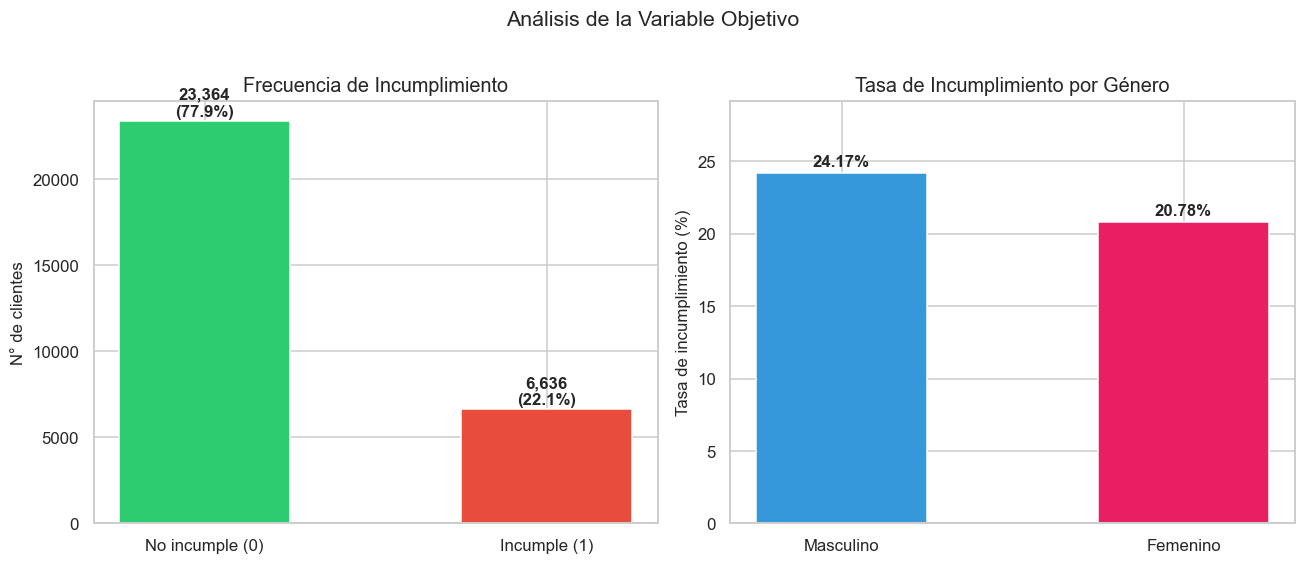

Tasa global de incumplimiento: 22.12%
Distribución: {0: np.int64(23364), 1: np.int64(6636)}


In [12]:
default_counts = df['default.payment.next.month'].value_counts().sort_index()
labels_def = ['No incumple (0)', 'Incumple (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
colores_def = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(labels_def, default_counts.values, color=colores_def, edgecolor='white', width=0.5)
for bar, val in zip(bars, default_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Frecuencia de Incumplimiento')
axes[0].set_ylabel('N° de clientes')

# Tasa de default por sexo
default_sex = df.groupby('SEX')['default.payment.next.month'].mean().round(4) * 100
sex_labels = ['Masculino', 'Femenino']
colors_sex = ['#3498db', '#e91e63']
bars2 = axes[1].bar(sex_labels, default_sex.values, color=colors_sex, edgecolor='white', width=0.5)
for bar, val in zip(bars2, default_sex.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Tasa de Incumplimiento por Género')
axes[1].set_ylabel('Tasa de incumplimiento (%)')
axes[1].set_ylim(0, max(default_sex.values) + 5)

plt.suptitle('Análisis de la Variable Objetivo', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_default.png', bbox_inches='tight', dpi=110)
plt.show()

print(f"Tasa global de incumplimiento: {df['default.payment.next.month'].mean()*100:.2f}%")
print(f"Distribución: {dict(default_counts)}")


### 4.7 Mapa de Correlaciones

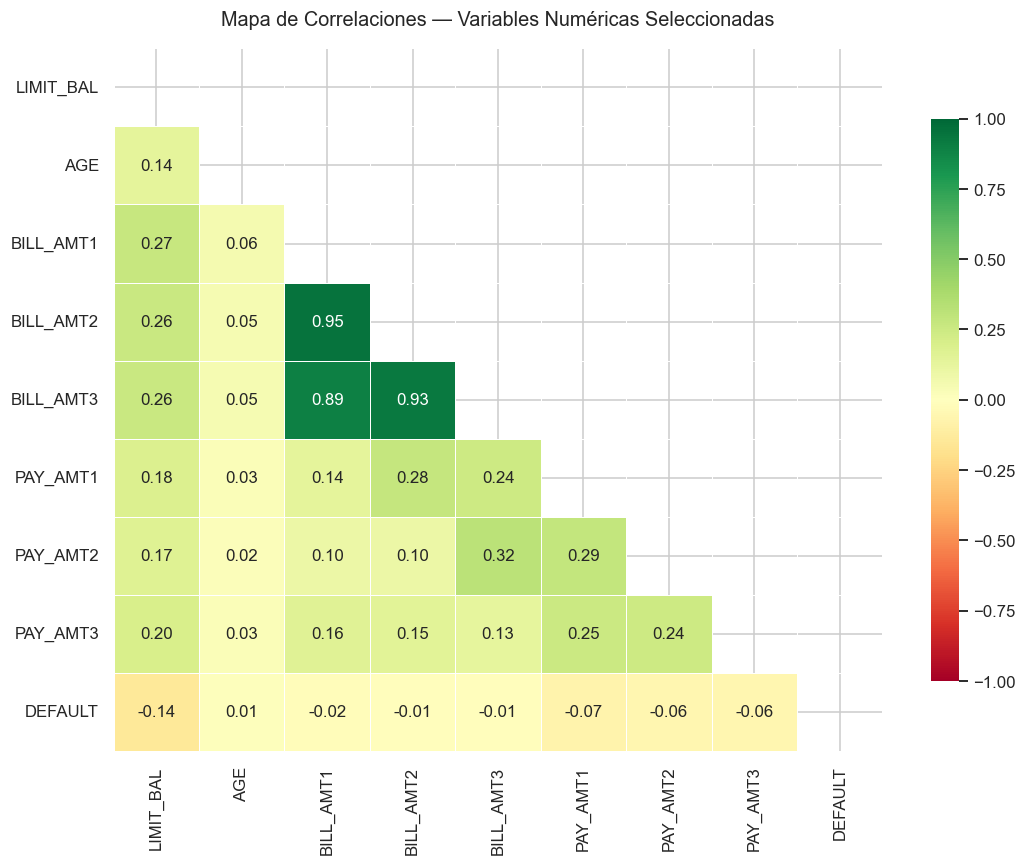


Correlaciones con la variable DEFAULT:
AGE          0.01
BILL_AMT3   -0.01
BILL_AMT2   -0.01
BILL_AMT1   -0.02
PAY_AMT3    -0.06
PAY_AMT2    -0.06
PAY_AMT1    -0.07
LIMIT_BAL   -0.14


In [13]:
vars_corr = ['LIMIT_BAL', 'AGE',
             'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'PAY_AMT1',  'PAY_AMT2',  'PAY_AMT3',
             'default.payment.next.month']

corr = df[vars_corr].corr()

# Renombrar para visualización
renombrar = {'default.payment.next.month': 'DEFAULT'}
corr = corr.rename(columns=renombrar, index=renombrar)

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Correlaciones — Variables Numéricas Seleccionadas', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../figures/fig_correlacion.png', bbox_inches='tight', dpi=110)
plt.show()

# Correlaciones con el target
print("\nCorrelaciones con la variable DEFAULT:")
corr_target = df[vars_corr].corr()['default.payment.next.month'].drop('default.payment.next.month')
print(corr_target.sort_values(ascending=False).to_string())


## 5. Estimación Puntual e Intervalos de Confianza *(ID1.3)*

La estimación paramétrica permite inferir características de la **población** (todos los clientes de tarjetas de crédito en Taiwan en 2005) a partir de la muestra disponible (n = 30,000).

### Marco teórico

**Intervalo de confianza para la media** (distribución t-Student):
$$\bar{x} \pm t_{\alpha/2, \, n-1} \cdot \frac{s}{\sqrt{n}}$$

**Intervalo de confianza para una proporción** (intervalo de Wilson, más preciso para proporciones):
$$\frac{\hat{p} + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

Para n = 30,000, los intervalos t-Student son prácticamente idénticos a los intervalos Z (por el TCL).

### Nivel de confianza utilizado: **95%** (α = 0.05)

In [14]:
def ic_media(serie, confianza=0.95):
    """IC para la media con t-Student."""
    data = serie.dropna().values
    n    = len(data)
    mu   = data.mean()
    se   = data.std(ddof=1) / np.sqrt(n)
    ic   = stats.t.interval(confianza, df=n - 1, loc=mu, scale=se)
    return mu, ic[0], ic[1], n, se

def ic_proporcion_wilson(exitos, n, confianza=0.95):
    """IC de Wilson para proporción."""
    p    = exitos / n
    z    = stats.norm.ppf((1 + confianza) / 2)
    denom  = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denom
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, centro - margen, centro + margen, n

# ─── Parámetros a estimar ─────────────────────────────────────────────────
estimaciones = {}

# 1. Media del límite de crédito
mu, li, ls, n, se = ic_media(df['LIMIT_BAL'])
estimaciones['Media LIMIT_BAL (NT$)'] = {
    'Estimación Puntual': f'{mu:,.0f}',
    'IC Inferior (95%)' : f'{li:,.0f}',
    'IC Superior (95%)' : f'{ls:,.0f}',
    'n': f'{n:,}',
    'Error Estándar'    : f'{se:,.2f}'
}

# 2. Proporción de incumplimiento (tasa de default)
defaults = int(df['default.payment.next.month'].sum())
n_total  = len(df)
p, li_p, ls_p, n_p = ic_proporcion_wilson(defaults, n_total)
estimaciones['Proporción de Default'] = {
    'Estimación Puntual': f'{p:.4f} ({p*100:.2f}%)',
    'IC Inferior (95%)' : f'{li_p:.4f} ({li_p*100:.2f}%)',
    'IC Superior (95%)' : f'{ls_p:.4f} ({ls_p*100:.2f}%)',
    'n': f'{n_p:,}',
    'Error Estándar'    : f'{np.sqrt(p*(1-p)/n_p):.6f}'
}

# 3. Media de la edad
mu_age, li_age, ls_age, n_age, se_age = ic_media(df['AGE'])
estimaciones['Media AGE (años)'] = {
    'Estimación Puntual': f'{mu_age:.2f}',
    'IC Inferior (95%)' : f'{li_age:.2f}',
    'IC Superior (95%)' : f'{ls_age:.2f}',
    'n': f'{n_age:,}',
    'Error Estándar'    : f'{se_age:.4f}'
}

# 4. Media del monto de factura (septiembre 2005)
mu_b1, li_b1, ls_b1, n_b1, se_b1 = ic_media(df['BILL_AMT1'])
estimaciones['Media BILL_AMT1 (NT$)'] = {
    'Estimación Puntual': f'{mu_b1:,.0f}',
    'IC Inferior (95%)' : f'{li_b1:,.0f}',
    'IC Superior (95%)' : f'{ls_b1:,.0f}',
    'n': f'{n_b1:,}',
    'Error Estándar'    : f'{se_b1:,.2f}'
}

# 5. Media del último pago (septiembre 2005)
mu_p1, li_p1, ls_p1, n_p1, se_p1 = ic_media(df['PAY_AMT1'])
estimaciones['Media PAY_AMT1 (NT$)'] = {
    'Estimación Puntual': f'{mu_p1:,.0f}',
    'IC Inferior (95%)' : f'{li_p1:,.0f}',
    'IC Superior (95%)' : f'{ls_p1:,.0f}',
    'n': f'{n_p1:,}',
    'Error Estándar'    : f'{se_p1:,.2f}'
}

tabla_ic = pd.DataFrame(estimaciones).T
print("ESTIMACIONES PUNTUALES E INTERVALOS DE CONFIANZA AL 95%")
print("=" * 70)
tabla_ic


ESTIMACIONES PUNTUALES E INTERVALOS DE CONFIANZA AL 95%


,Estimación Puntual,IC Inferior (95%),IC Superior (95%),n,Error Estándar
Media LIMIT_BAL (NT$),"164,247","162,864","165,629","30,000",705.47
Proporción de Default,0.2212 (22.12%),0.2165 (21.65%),0.2259 (22.59%),"30,000",0.002396
Media AGE (años),35.49,35.38,35.59,"30,000",0.0532
Media BILL_AMT1 (NT$),"51,223","50,390","52,057","30,000",425.14
Media PAY_AMT1 (NT$),"5,664","5,476","5,851","30,000",95.63


### 5.1 Tasa de Default por Género — Estimación e IC

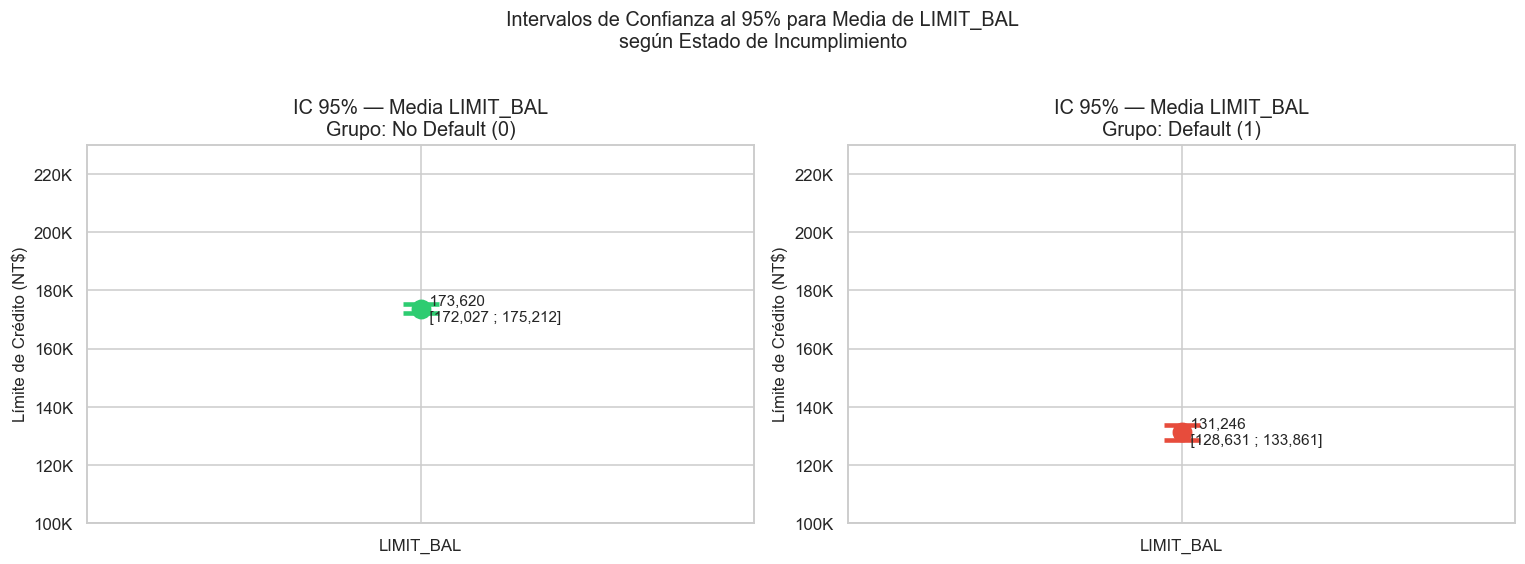


Media LIMIT_BAL (No Default): NT$173,620
Media LIMIT_BAL (Default):     NT$131,246


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IC para media de LIMIT_BAL
for ax, (grupo_val, grupo_nombre, color) in zip(
    axes,
    [(0, 'No Default (0)', '#2ecc71'), (1, 'Default (1)', '#e74c3c')]
):
    data_grupo = df[df['default.payment.next.month'] == grupo_val]['LIMIT_BAL']
    mu_g, li_g, ls_g, n_g, se_g = ic_media(data_grupo)

    ax.errorbar(
        x=['LIMIT_BAL'],
        y=[mu_g],
        yerr=[[mu_g - li_g], [ls_g - mu_g]],
        fmt='o', color=color, markersize=12, linewidth=3, capsize=12, capthick=3
    )
    ax.set_title(f'IC 95% — Media LIMIT_BAL\nGrupo: {grupo_nombre}')
    ax.set_ylabel('Límite de Crédito (NT$)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.text(0, mu_g, f'  {mu_g:,.0f}\n  [{li_g:,.0f} ; {ls_g:,.0f}]',
            va='center', fontsize=10)
    ax.set_ylim(100000, 230000)

plt.suptitle('Intervalos de Confianza al 95% para Media de LIMIT_BAL\nsegún Estado de Incumplimiento',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_ic_limitbal.png', bbox_inches='tight', dpi=110)
plt.show()

print(f"\nMedia LIMIT_BAL (No Default): NT${df[df['default.payment.next.month']==0]['LIMIT_BAL'].mean():,.0f}")
print(f"Media LIMIT_BAL (Default):     NT${df[df['default.payment.next.month']==1]['LIMIT_BAL'].mean():,.0f}")


**Interpretación:**
- El límite de crédito promedio de los clientes que **no incumplieron** (No Default) es significativamente mayor que el de los que sí incumplieron, lo que sugiere que el banco otorgó límites más altos a clientes de menor riesgo, o que los clientes con mayor capacidad financiera tienen menor probabilidad de incumplir.
- La tasa de incumplimiento estimada es del **22.12%** [IC 95%: 21.65% – 22.59%], lo que indica que aproximadamente 1 de cada 5 clientes incumplió su pago.
- La media de edad es de **35.49 años** [IC 95%: 35.38 – 35.59], lo que corresponde a una población adulta joven.

## 6. Prueba de Hipótesis *(ID1.4)*

Se aplican pruebas de hipótesis para contrastar afirmaciones sobre parámetros poblacionales.
El **nivel de significancia** utilizado en todas las pruebas es **α = 0.05**.

---

### Prueba 1: ¿Difiere el límite de crédito entre clientes que incumplieron y los que no?

**Tipo de prueba:** t-test de Welch para dos muestras independientes (no asume igualdad de varianzas)
**Variable:** `LIMIT_BAL` (numérica continua)
**Grupos:** Default = 0 vs. Default = 1

**Hipótesis:**
- H₀: μ_NoDefault = μ_Default (no existe diferencia en el límite de crédito promedio)
- H₁: μ_NoDefault ≠ μ_Default (existe diferencia significativa, prueba bilateral)

In [16]:
grupo0 = df[df['default.payment.next.month'] == 0]['LIMIT_BAL']
grupo1 = df[df['default.payment.next.month'] == 1]['LIMIT_BAL']

# Welch t-test (no asume varianzas iguales)
t_stat, p_valor = ttest_ind(grupo0, grupo1, equal_var=False)
# Mann-Whitney U como prueba no paramétrica complementaria
u_stat, p_mw    = mannwhitneyu(grupo0, grupo1, alternative='two-sided')

print("=" * 60)
print("PRUEBA 1: Límite de Crédito según Estado de Incumplimiento")
print("=" * 60)
print(f"\nEstadísticas descriptivas:")
print(f"  No Default (n={len(grupo0):,}): media = NT${grupo0.mean():,.0f}, σ = NT${grupo0.std():,.0f}")
print(f"  Default    (n={len(grupo1):,}): media = NT${grupo1.mean():,.0f}, σ = NT${grupo1.std():,.0f}")
print(f"\nWelch t-test:")
print(f"  t = {t_stat:.4f}  |  p-value = {p_valor:.2e}")
print(f"\nMann-Whitney U (no paramétrico):")
print(f"  U = {u_stat:.0f}  |  p-value = {p_mw:.2e}")

alpha = 0.05
print(f"\nDecisión (α = {alpha}):")
if p_valor < alpha:
    print(f"  ✓ Se RECHAZA H₀ (p = {p_valor:.2e} < {alpha})")
    print(f"  Conclusión: Existe diferencia estadísticamente significativa en el límite de")
    print(f"  crédito entre clientes que incumplieron y los que no.")
else:
    print(f"  ✗ No se rechaza H₀ (p = {p_valor:.2e} ≥ {alpha})")

# Tamaño del efecto (d de Cohen)
pooled_std = np.sqrt((grupo0.std()**2 + grupo1.std()**2) / 2)
d_cohen = (grupo0.mean() - grupo1.mean()) / pooled_std
print(f"\nTamaño del efecto (d de Cohen): {d_cohen:.3f}")
magnitude = 'pequeño' if abs(d_cohen) < 0.5 else ('mediano' if abs(d_cohen) < 0.8 else 'grande')
print(f"  Interpretación: efecto {magnitude} (|d| = {abs(d_cohen):.3f})")


PRUEBA 1: Límite de Crédito según Estado de Incumplimiento

Estadísticas descriptivas:
  No Default (n=23,364): media = NT$173,620, σ = NT$124,181
  Default    (n=6,636): media = NT$131,246, σ = NT$108,667

Welch t-test:
  t = 27.1300  |  p-value = 2.30e-157

Mann-Whitney U (no paramétrico):
  U = 94737305  |  p-value = 4.26e-169

Decisión (α = 0.05):
  ✓ Se RECHAZA H₀ (p = 2.30e-157 < 0.05)
  Conclusión: Existe diferencia estadísticamente significativa en el límite de
  crédito entre clientes que incumplieron y los que no.

Tamaño del efecto (d de Cohen): 0.363
  Interpretación: efecto pequeño (|d| = 0.363)


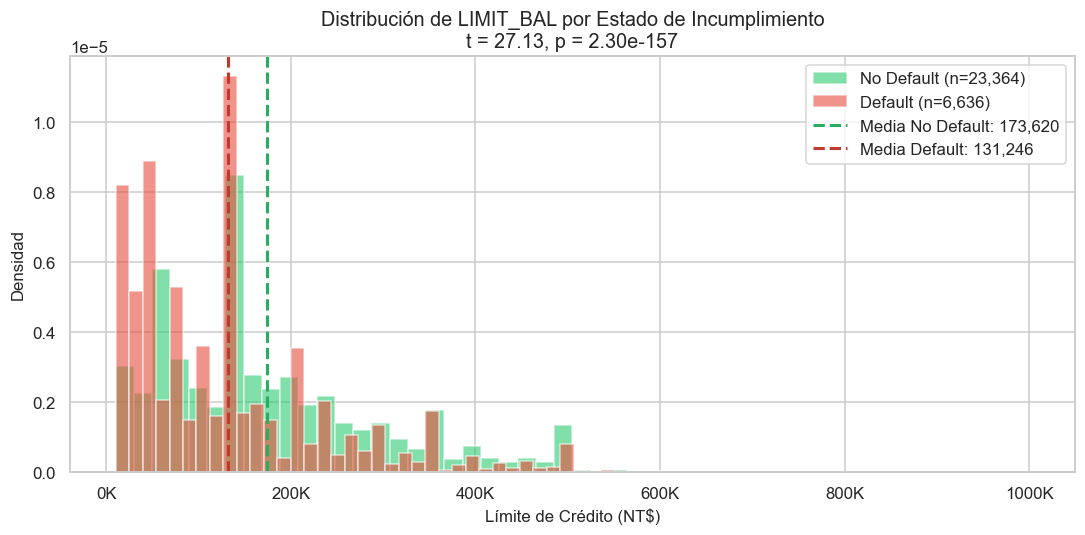

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(grupo0, bins=50, alpha=0.6, color='#2ecc71', label=f'No Default (n={len(grupo0):,})', density=True)
ax.hist(grupo1, bins=50, alpha=0.6, color='#e74c3c', label=f'Default (n={len(grupo1):,})', density=True)

ax.axvline(grupo0.mean(), color='#27ae60', linestyle='--', linewidth=2, label=f'Media No Default: {grupo0.mean():,.0f}')
ax.axvline(grupo1.mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'Media Default: {grupo1.mean():,.0f}')

ax.set_title(f'Distribución de LIMIT_BAL por Estado de Incumplimiento\nt = {t_stat:.2f}, p = {p_valor:.2e}')
ax.set_xlabel('Límite de Crédito (NT$)')
ax.set_ylabel('Densidad')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_test1.png', bbox_inches='tight', dpi=110)
plt.show()


---

### Prueba 2: ¿Existe asociación entre el género y la tasa de incumplimiento?

**Tipo de prueba:** Chi-cuadrado (χ²) de independencia
**Variables:** `SEX` (categórica binaria) × `default.payment.next.month` (binaria)

**Hipótesis:**
- H₀: El incumplimiento de pago es **independiente** del género del cliente
- H₁: Existe **asociación** entre el género y la probabilidad de incumplimiento

In [18]:
tabla_cont = pd.crosstab(
    df['SEX'].map({1: 'Masculino', 2: 'Femenino'}),
    df['default.payment.next.month'].map({0: 'No Default', 1: 'Default'}),
    margins=True
)
print("Tabla de contingencia: Género × Default")
print(tabla_cont.to_string())

# Tabla de proporciones por fila
tabla_prop = pd.crosstab(
    df['SEX'].map({1: 'Masculino', 2: 'Femenino'}),
    df['default.payment.next.month'].map({0: 'No Default', 1: 'Default'}),
    normalize='index'
).round(4) * 100
print("\nProporciones (%) por género:")
print(tabla_prop.to_string())

# Chi-cuadrado
tabla_chi = pd.crosstab(df['SEX'], df['default.payment.next.month'])
chi2_stat, p_chi2, dof, expected = chi2_contingency(tabla_chi)

print(f"\n{'='*60}")
print("PRUEBA 2: Chi-cuadrado de independencia")
print(f"{'='*60}")
print(f"χ² = {chi2_stat:.4f}  |  gl = {dof}  |  p-value = {p_chi2:.4f}")

# Valor crítico
chi2_critico = stats.chi2.ppf(0.95, df=dof)
print(f"Valor crítico χ²(gl={dof}, α=0.05) = {chi2_critico:.4f}")

if p_chi2 < 0.05:
    print(f"\nDecisión: Se RECHAZA H₀ (p = {p_chi2:.4f} < 0.05)")
    print("Conclusión: Existe asociación estadísticamente significativa entre el género y el incumplimiento.")
else:
    print(f"\nDecisión: No se rechaza H₀ (p = {p_chi2:.4f} ≥ 0.05)")

# V de Cramér (tamaño del efecto)
n_tot = tabla_chi.values.sum()
v_cramer = np.sqrt(chi2_stat / (n_tot * min(tabla_chi.shape[0]-1, tabla_chi.shape[1]-1)))
print(f"\nV de Cramér (tamaño del efecto): {v_cramer:.4f}")
print(f"  Interpretación: {'efecto negligible' if v_cramer < 0.1 else ('efecto pequeño' if v_cramer < 0.3 else 'efecto moderado')}")


Tabla de contingencia: Género × Default
default.payment.next.month  Default  No Default    All
SEX                                                   
Masculino                      2873        9015  11888
Femenino                       3763       14349  18112
All                            6636       23364  30000

Proporciones (%) por género:
default.payment.next.month  Default  No Default
SEX                                            
Masculino                     24.17       75.83
Femenino                      20.78       79.22

PRUEBA 2: Chi-cuadrado de independencia
χ² = 47.7088  |  gl = 1  |  p-value = 0.0000
Valor crítico χ²(gl=1, α=0.05) = 3.8415

Decisión: Se RECHAZA H₀ (p = 0.0000 < 0.05)
Conclusión: Existe asociación estadísticamente significativa entre el género y el incumplimiento.

V de Cramér (tamaño del efecto): 0.0399
  Interpretación: efecto negligible


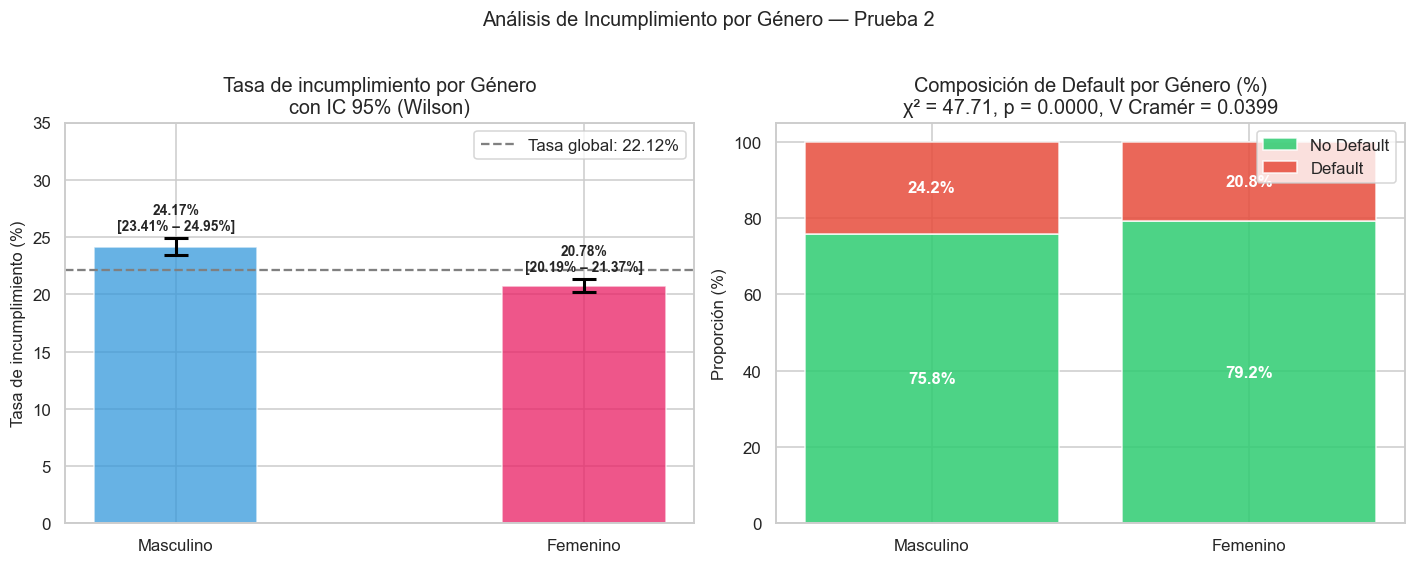


Resumen:
  Masculino: 24.17%  [IC 95%: 23.41% – 24.95%]
  Femenino: 20.78%  [IC 95%: 20.19% – 21.37%]


In [19]:
# Visualización Prueba 2: Tasa de default con IC por género
sexos   = ['Masculino', 'Femenino']
valores = [1, 2]

tasas_sex, li_sex, ls_sex = [], [], []
for val in valores:
    n_g   = int((df['SEX'].astype(int) == val).sum())
    p_g   = df[df['SEX'].astype(int) == val]['default.payment.next.month'].mean()
    _p, li_w, ls_w, _n = ic_proporcion_wilson(int(p_g * n_g), n_g)
    tasas_sex.append(p_g * 100)
    li_sex.append(li_w * 100)
    ls_sex.append(ls_w * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: barras con IC
colores_sex = ['#3498db', '#e91e63']
for i, (sexo, tasa, li, ls, color) in enumerate(zip(sexos, tasas_sex, li_sex, ls_sex, colores_sex)):
    axes[0].bar(sexo, tasa, color=color, alpha=0.75, edgecolor='white', width=0.4)
    axes[0].errorbar(i, tasa, yerr=[[tasa - li], [ls - tasa]],
                     fmt='none', color='black', capsize=8, capthick=2, linewidth=2)
    axes[0].text(i, ls + 0.4, f'{tasa:.2f}%\n[{li:.2f}% – {ls:.2f}%]',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].axhline(df['default.payment.next.month'].mean() * 100, color='gray',
                linestyle='--', label=f'Tasa global: {df["default.payment.next.month"].mean()*100:.2f}%')
axes[0].set_title('Tasa de incumplimiento por Género\ncon IC 95% (Wilson)')
axes[0].set_ylabel('Tasa de incumplimiento (%)')
axes[0].set_ylim(0, 35)
axes[0].legend()

# Panel derecho: barras apiladas 100%
sex_map = df['SEX'].map({1: 'Masculino', 2: 'Femenino'})
default_sex2 = df.groupby(sex_map)['default.payment.next.month']
prop_no_def  = default_sex2.apply(lambda x: (x == 0).mean() * 100).reindex(['Masculino', 'Femenino'])
prop_def     = default_sex2.apply(lambda x: (x == 1).mean() * 100).reindex(['Masculino', 'Femenino'])

axes[1].bar(['Masculino', 'Femenino'], prop_no_def.values, color='#2ecc71', label='No Default', alpha=0.85)
axes[1].bar(['Masculino', 'Femenino'], prop_def.values,    color='#e74c3c', label='Default',
            bottom=prop_no_def.values, alpha=0.85)
for i, (nd, d) in enumerate(zip(prop_no_def.values, prop_def.values)):
    axes[1].text(i, nd / 2,    f'{nd:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    axes[1].text(i, nd + d / 2, f'{d:.1f}%',  ha='center', va='center', color='white', fontweight='bold')

axes[1].set_title(f'Composición de Default por Género (%)\nχ² = {chi2_stat:.2f}, p = {p_chi2:.4f}, V Cramér = {v_cramer:.4f}')
axes[1].set_ylabel('Proporción (%)')
axes[1].set_ylim(0, 105)
axes[1].legend(loc='upper right')

plt.suptitle('Análisis de Incumplimiento por Género — Prueba 2', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_test2.png', bbox_inches='tight', dpi=110)
plt.show()

print("\nResumen:")
for sexo, tasa, li, ls in zip(sexos, tasas_sex, li_sex, ls_sex):
    print(f"  {sexo}: {tasa:.2f}%  [IC 95%: {li:.2f}% – {ls:.2f}%]")

---

### Prueba 3: ¿La tasa de incumplimiento varía según el nivel educacional?

**Tipo de prueba:** Chi-cuadrado (χ²) de independencia
**Variables:** `EDUCATION` (categórica ordinal) × `default.payment.next.month` (binaria)

**Hipótesis:**
- H₀: La tasa de incumplimiento es igual en todos los niveles educacionales
- H₁: Al menos un nivel educacional presenta una tasa de incumplimiento diferente

Tabla de contingencia: Educación × Default
default.payment.next.month  Default  No Default    All
EDUCATION_label                                       
Posgrado                       2036        8549  10585
Secundaria                     1237        3680   4917
Universidad                    3330       10700  14030
All                            6603       22929  29532

Tasa de incumplimiento por nivel educacional:
                     N  Tasa Default (%)
EDUCATION_label                         
Posgrado         10585             19.23
Secundaria        4917             25.16
Universidad      14030             23.73

PRUEBA 3: Chi-cuadrado (Educación × Default)
χ² = 96.9998  |  gl = 2  |  p-value = 0.000000
V de Cramér = 0.0573  (efecto negligible)

Decisión: Se RECHAZA H₀ (p = 0.000000 < 0.05)
Conclusión: Existe asociación significativa entre el nivel educacional y el incumplimiento.


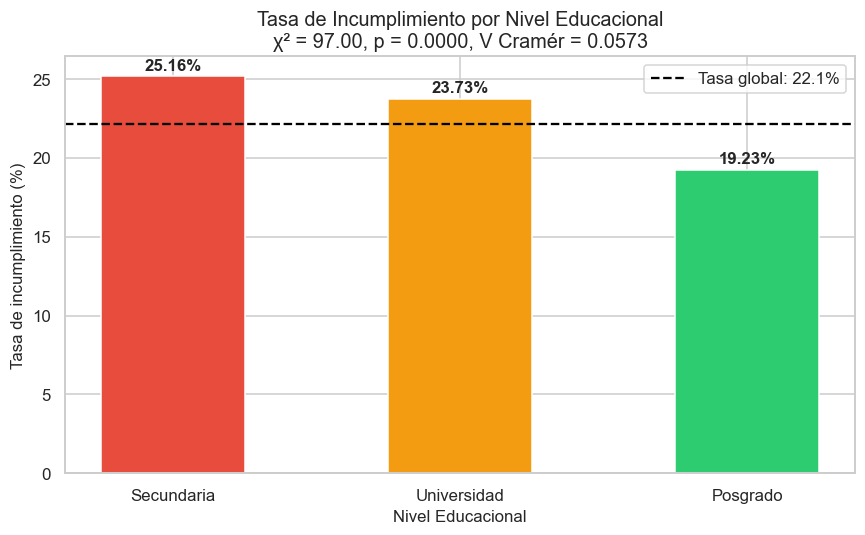

In [20]:
# Considerar solo los niveles educacionales principales (1=Posgrado, 2=Universidad, 3=Secundaria);
# se excluyen 468 registros: el código 4 ("otros", documentado en la ficha oficial)
# y los códigos 0, 5 y 6 (no documentados), por no ser comparables como nivel de estudios
edu_filtrado = df[df['EDUCATION'].astype(int).isin([1, 2, 3])]
edu_filtrado = edu_filtrado.copy()
edu_filtrado['EDUCATION_label'] = edu_filtrado['EDUCATION'].astype(int).map({
    1: 'Posgrado', 2: 'Universidad', 3: 'Secundaria'
})

tabla_edu = pd.crosstab(
    edu_filtrado['EDUCATION_label'],
    edu_filtrado['default.payment.next.month'].map({0: 'No Default', 1: 'Default'}),
    margins=True
)
print("Tabla de contingencia: Educación × Default")
print(tabla_edu.to_string())

# Tasas de default por educación
tasas = edu_filtrado.groupby('EDUCATION_label')['default.payment.next.month'].agg(
    ['mean', 'count']
).rename(columns={'mean': 'Tasa Default', 'count': 'N'})
tasas['Tasa Default (%)'] = (tasas['Tasa Default'] * 100).round(2)
print("\nTasa de incumplimiento por nivel educacional:")
print(tasas[['N', 'Tasa Default (%)']].to_string())

# Chi-cuadrado
tabla_chi2 = pd.crosstab(edu_filtrado['EDUCATION_label'], edu_filtrado['default.payment.next.month'])
chi2_edu, p_edu, dof_edu, _ = chi2_contingency(tabla_chi2)

# V de Cramér (tamaño del efecto)
n_edu = tabla_chi2.values.sum()
v_cramer_edu = np.sqrt(chi2_edu / (n_edu * min(tabla_chi2.shape[0]-1, tabla_chi2.shape[1]-1)))
magnitude_edu = 'negligible' if v_cramer_edu < 0.1 else ('pequeño' if v_cramer_edu < 0.3 else 'moderado')

print(f"\n{'='*60}")
print("PRUEBA 3: Chi-cuadrado (Educación × Default)")
print(f"{'='*60}")
print(f"χ² = {chi2_edu:.4f}  |  gl = {dof_edu}  |  p-value = {p_edu:.6f}")
print(f"V de Cramér = {v_cramer_edu:.4f}  (efecto {magnitude_edu})")

if p_edu < 0.05:
    print(f"\nDecisión: Se RECHAZA H₀ (p = {p_edu:.6f} < 0.05)")
    print("Conclusión: Existe asociación significativa entre el nivel educacional y el incumplimiento.")
else:
    print(f"\nDecisión: No se rechaza H₀ (p = {p_edu:.6f} ≥ 0.05)")

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
tasas_plot = tasas.sort_values('Tasa Default (%)', ascending=False)
colores = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(tasas_plot.index, tasas_plot['Tasa Default (%)'], color=colores, edgecolor='white', width=0.5)
for bar, val in zip(bars, tasas_plot['Tasa Default (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
ax.axhline(y=df['default.payment.next.month'].mean()*100, color='black',
           linestyle='--', label=f'Tasa global: {df["default.payment.next.month"].mean()*100:.1f}%')
ax.set_title(f'Tasa de Incumplimiento por Nivel Educacional\nχ² = {chi2_edu:.2f}, p = {p_edu:.4f}, V Cramér = {v_cramer_edu:.4f}')
ax.set_xlabel('Nivel Educacional')
ax.set_ylabel('Tasa de incumplimiento (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig_test3.png', bbox_inches='tight', dpi=110)
plt.show()

## 7. Resumen de Resultados e Interpretación

### 7.1 Resumen de Pruebas de Hipótesis

In [21]:
# Grados de libertad de Welch-Satterthwaite (cálculo exacto, no aproximación por n)
_a = df[df['default.payment.next.month'] == 0]['LIMIT_BAL'].dropna()
_b = df[df['default.payment.next.month'] == 1]['LIMIT_BAL'].dropna()
_va, _vb, _na, _nb = _a.var(ddof=1), _b.var(ddof=1), len(_a), len(_b)
welch_df = (_va/_na + _vb/_nb)**2 / ((_va/_na)**2/(_na-1) + (_vb/_nb)**2/(_nb-1))
resumen_tests = pd.DataFrame({
    'Prueba': [
        'T1: LIMIT_BAL — Default vs No Default',
        'T2: Género × Incumplimiento',
        'T3: Educación × Incumplimiento'
    ],
    'Tipo de prueba': [
        'Welch t-test (bilateral)',
        'Chi-cuadrado (χ²)',
        'Chi-cuadrado (χ²)'
    ],
    'Estadístico': [
        f't = {t_stat:.4f}',
        f'χ² = {chi2_stat:.4f}',
        f'χ² = {chi2_edu:.4f}'
    ],
    'gl': [
        f'~{welch_df:,.0f}'.replace(',', ' '),
        str(dof),
        str(dof_edu)
    ],
    'p-value': [
        f'{p_valor:.2e}',
        f'{p_chi2:.4f}',
        f'{p_edu:.6f}'
    ],
    'Decisión (α=0.05)': [
        'Rechaza H₀' if p_valor < 0.05 else 'No rechaza H₀',
        'Rechaza H₀' if p_chi2 < 0.05 else 'No rechaza H₀',
        'Rechaza H₀' if p_edu  < 0.05 else 'No rechaza H₀',
    ],
    'Tamaño del efecto': [
        f'd Cohen = {d_cohen:.3f} ({"pequeño" if abs(d_cohen)<0.5 else "mediano" if abs(d_cohen)<0.8 else "grande"})',
        f'V Cramér = {v_cramer:.4f} ({"negligible" if v_cramer<0.1 else "pequeño" if v_cramer<0.3 else "moderado"})',
        f'V Cramér = {v_cramer_edu:.4f} ({"negligible" if v_cramer_edu<0.1 else "pequeño" if v_cramer_edu<0.3 else "moderado"})',
    ]
}).set_index('Prueba')

pd.set_option('display.max_colwidth', 50)
resumen_tests

,Tipo de prueba,Estadístico,gl,p-value,Decisión (α=0.05),Tamaño del efecto
Prueba,,,,,,
T1: LIMIT_BAL — Default vs No Default,Welch t-test (bilateral),t = 27.1300,~12 001,2.30e-157,Rechaza H₀,d Cohen = 0.363 (pequeño)
T2: Género × Incumplimiento,Chi-cuadrado (χ²),χ² = 47.7088,1,0.0000,Rechaza H₀,V Cramér = 0.0399 (negligible)
T3: Educación × Incumplimiento,Chi-cuadrado (χ²),χ² = 96.9998,2,0.000000,Rechaza H₀,V Cramér = 0.0573 (negligible)


### 7.2 Interpretación Preliminar de Resultados

Los análisis realizados permiten extraer las siguientes conclusiones respecto al riesgo de incumplimiento crediticio, con implicancias directas para la **toma de decisiones bajo incertidumbre** en el ámbito del riesgo crediticio.

---

#### Estadística Descriptiva *(ID1.2)*

- El dataset contiene **30,000 clientes** con una tasa de incumplimiento del **22.1%**, lo que representa una proporción relevante que justifica la necesidad de modelos predictivos y estrategias de gestión proactiva del riesgo.
- La variable `LIMIT_BAL` presenta alta asimetría positiva (asimetría ≈ 1.13; media NT\$164,247 > mediana NT\$140,000), indicando que la distribución de los límites de crédito no es simétrica: la mayoría de los clientes concentra límites moderados mientras un segmento minoritario accede a límites muy elevados.
- Las variables de facturas (`BILL_AMT*`) exhiben alta variabilidad (CV > 100%) y asimetría extrema, lo que dificulta establecer un perfil único de deudor en riesgo y refuerza la necesidad de métodos estadísticos robustos.
- La correlación entre facturas consecutivas supera r = 0.90, lo que es consistente con la naturaleza acumulativa de los saldos de tarjeta de crédito.
- Las variables de pago (`PAY_AMT*`) presentan curtosis muy elevada (hasta 1,641 para PAY_AMT2), evidenciando pagos extremadamente concentrados en valores bajos con presencia de pagos atípicamente altos.

---

#### Estimación Paramétrica *(ID1.3)*

Las estimaciones permiten caracterizar la **población de clientes de tarjetas de crédito en Taiwán, 2005**, extrapolando desde la muestra disponible (n = 30,000):

- El límite de crédito promedio se estima en **NT\$164,247** [IC 95%: 162,864 – 165,629]. Este intervalo estrecho (amplitud NT\$2,765) refleja la alta precisión alcanzada con n = 30,000 y permite planificar políticas de crédito con fundamento estadístico robusto.
- La tasa de incumplimiento poblacional se estima en **22.12%** [IC 95%: 21.65% – 22.59%]. Esto implica que, bajo condiciones similares, entre 1 de cada 5 y 1 de cada 4 clientes incumplirá su pago, lo que constituye un parámetro clave para calcular provisiones y reservas de capital.
- La edad promedio es de **35.49 años** [IC 95%: 35.38 – 35.59], correspondiente a una población adulta joven-media.
- La factura promedio de septiembre 2005 fue **NT\$51,223** [IC 95%: 50,390 – 52,057], con un pago promedio de **NT\$5,664** [IC 95%: 5,476 – 5,851]. El pago promedio equivale aproximadamente al 11% de la factura promedio; esta comparación agregada no representa el porcentaje pagado individualmente por cada cliente.

---

#### Pruebas de Hipótesis *(ID1.4)*

Todas las pruebas se realizaron con nivel de significancia α = 0.05. Los resultados estadísticos y su relevancia práctica son:

- **Prueba 1 (LIMIT_BAL por incumplimiento):** Se rechaza H₀ con evidencia muy fuerte (t = 27.13, p ≈ 2.3×10⁻¹⁵⁷). Los clientes que incumplieron tienen en promedio NT\$42,374 menos de límite de crédito (NT\$131,246 vs NT\$173,620). El efecto es estadísticamente robusto (d Cohen ≈ 0.363, efecto pequeño-mediano), lo que sugiere que el límite de crédito captura —al menos parcialmente— la capacidad de pago del cliente. **Implicancia decisional:** Un umbral de límite de crédito puede orientar políticas diferenciadas de riesgo y cobranza.

- **Prueba 2 (Género × incumplimiento):** Se rechaza H₀ (χ² = 47.71, p < 0.0001), pero el tamaño del efecto es negligible (V Cramér ≈ 0.040). Los hombres muestran mayor tasa de incumplimiento (24.2% vs 20.8%), pero esta diferencia tiene escaso valor predictivo a nivel individual. **Implicancia decisional:** El género no justifica por sí solo políticas diferenciadas; su valor analítico es marginal.

- **Prueba 3 (Educación × incumplimiento):** Se rechaza H₀ (χ² = 97.00, p < 0.0001), con efecto estadísticamente significativo aunque de magnitud limitada (V Cramér ≈ 0.057). Los clientes con educación secundaria presentan la mayor tasa de default (~25%), seguidos de universitarios (~24%) y de posgrado (~19%). **Implicancia decisional:** El nivel educacional puede contribuir marginalmente en modelos multivariados de scoring crediticio, pero no es determinante por sí solo.

---

#### Síntesis para la Toma de Decisiones

Desde la perspectiva de la **gestión de riesgo crediticio bajo incertidumbre**, los hallazgos muestran que:

1. La **tasa de incumplimiento del 22.1%** constituye el parámetro de referencia central para modelar provisiones y pérdidas esperadas (EL = PD × LGD × EAD).
2. El **límite de crédito** es la variable con mayor poder discriminante entre cumplidores e incumplidores, sugiriendo su uso como variable de segmentación de riesgo.
3. Las variables demográficas (género, educación) muestran asociación estadísticamente significativa pero efectos prácticos pequeños, lo que es consistente con la literatura sobre discriminación estadística vs. discriminación económicamente relevante.
4. La alta asimetría y curtosis de los montos de pago y factura subrayan que **los valores esperados por sí solos son insuficientes** para la toma de decisiones: es necesario considerar percentiles y distribuciones completas para evaluar riesgos de cola.

Estos resultados sientan las bases estadísticas para las fases siguientes del proyecto, donde se evaluarán modelos predictivos formales para la estimación de la probabilidad de incumplimiento (PD).

---

*Análisis realizado con Python 3.12 · pandas · scipy · matplotlib · seaborn*

## 8. Conclusiones Generales

El presente análisis aplicó métodos de estadística descriptiva, estimación paramétrica y pruebas de hipótesis sobre el dataset *Default of Credit Card Clients* (UCI, Taiwán 2005), con el objetivo de caracterizar el comportamiento de incumplimiento crediticio y generar evidencia estadística para la toma de decisiones bajo incertidumbre.

### Hallazgos principales

**1. Caracterización descriptiva del riesgo:**
La muestra de 30,000 clientes presenta una tasa de incumplimiento del 22.1%, con alta heterogeneidad en los montos de factura y pago (elevada asimetría y curtosis). El límite de crédito promedio es NT\$164,247, con fuerte asimetría positiva que indica que la media sobreestima el límite típico del cliente (mediana NT\$140,000). Estos resultados muestran que un solo parámetro resumen es insuficiente para describir la variabilidad real del portafolio.

**2. Precisión de las estimaciones poblacionales:**
Con n = 30,000 observaciones, los intervalos de confianza al 95% son notablemente estrechos. La tasa de incumplimiento poblacional se estima con una amplitud de ±0.47 puntos porcentuales, nivel de precisión suficiente para tomar decisiones operativas (provisiones, alertas tempranas) dentro del alcance de la muestra analizada, considerando sus limitaciones de representatividad temporal y geográfica.

**3. Variables con asociación estadísticamente significativa al incumplimiento:**
Las tres hipótesis contrastadas fueron rechazadas con alto nivel de significancia estadística (p < 0.0001 en todos los casos). Sin embargo, solo el límite de crédito (d Cohen ≈ 0.363) muestra un efecto de magnitud prácticamente relevante; las variables género y nivel educacional presentan efectos negligibles a pequeños (V Cramér < 0.06), lo que implica que su relevancia estadística no se traduce en poder predictivo sustantivo.

**4. Limitaciones del análisis:**
- Los resultados son descriptivos e inferenciales bivariados; no permiten establecer causalidad ni controlar por variables de confusión.
- La significancia estadística con muestras grandes (n = 30,000) detecta diferencias muy pequeñas como "significativas"; el tamaño del efecto es el indicador más relevante para la toma de decisiones.
- El análisis se restringe al periodo abril–septiembre 2005 en Taiwán; la generalización a otros contextos requiere cautela metodológica.

### Proyecciones para fases siguientes

Los hallazgos de esta fase constituyen el diagnóstico estadístico base del proyecto. Las fases siguientes deberán:
- Analizar las variables de historial de pago (`PAY_0`–`PAY_6`) como predictores del incumplimiento.
- Evaluar modelos de clasificación multivariados (regresión logística, árboles de decisión) para estimar la probabilidad de incumplimiento (PD) integrando todas las variables disponibles.
- Calcular métricas de rendimiento del modelo (AUC-ROC, precisión, recall) que permitan comparar su utilidad práctica para la gestión del riesgo.

## 9. Referencias

1. **Yeh, I.-C., & Lien, C.-H. (2009).** The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480. 

2. Lichman, M. (2013). *UCI Machine Learning Repository* [Dataset]. University of California, School of Information and Computer Science. http://archive.ics.uci.edu/ml

3. **Agresti, A. (2013).** *Categorical Data Analysis* (3rd ed.). Wiley.

4. **Cohen, J. (1988).** *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.

5. **Montgomery, D. C., & Runger, G. C. (2014).** *Applied Statistics and Probability for Engineers* (6th ed.). Wiley.

6. **Wilson, E. B. (1927).** Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association, 22*(158), 209–212. https://doi.org/10.2307/2276774

---

> **Nota metodológica:** Los valores faltantes presentes en el dataset empleado (`UCI_Credit_Card_con_faltantes.csv`) fueron introducidos de forma controlada bajo el mecanismo MCAR (*Missing Completely At Random*, semilla 42) e imputados con mediana (`LIMIT_BAL`) y moda (`PAY_0`) previo al análisis. El dataset original sin faltantes está disponible en `UCI_Credit_Card.csv`.